# 04 — Anomaly Detection (Isolation Forest)

**Objective:** Apply a two-stage anomaly detection pipeline:
1. **Classical** — IQR 1.5× fence and Z-score > 3 on key columns.
2. **Machine Learning** — Isolation Forest (contamination=2.3%)
   on all 10 scaled clustering features.

The output is a continuous `FRAUD_RISK_SCORE` (0–100) for every
customer, plus binary anomaly flags.

**Input:** `data/processed/clustered_customers.csv`  
**Output:** `data/processed/master_customers.csv`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import ensure_directories, PROCESSED_DATA_DIR, CLUSTERING_FEATURES
ensure_directories()

## 1. Load Clustered Data & Reconstruct Scaled Array

In [2]:
import pandas as pd
import joblib
from src.utils import SCALER_PATH

df = pd.read_csv(PROCESSED_DATA_DIR / "clustered_customers.csv", index_col="CUST_ID")
print(f"Loaded clustered data: {df.shape[0]} rows, {df.shape[1]} columns")

# Reload the fitted scaler and reconstruct the scaled feature matrix
scaler = joblib.load(SCALER_PATH)
scaled_array = scaler.transform(df[CLUSTERING_FEATURES])
print(f"Scaled array shape: {scaled_array.shape}")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_182780\733124480.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Loaded clustered data: 8949 rows, 27 columns
Scaled array shape: (8949, 10)


## 2. Classic Outlier Flags (IQR + Z-Score)

For BALANCE, PURCHASES, and CASH_ADVANCE:
- Flag as outlier if **beyond IQR 1.5× fence** OR **Z-score > 3**.
- A composite `CLASSIC_OUTLIER_FLAG` is 1 if *any* of the three
  individual flags is True.

In [3]:
from src.anomaly import flag_classic_outliers

df = flag_classic_outliers(df)

  ✓ BALANCE_OUTLIER: 695 outliers (7.8%)
  ✓ PURCHASE_OUTLIER: 808 outliers (9.0%)
  ✓ CASH_OUTLIER: 1030 outliers (11.5%)
  ✓ Composite CLASSIC_OUTLIER_FLAG: 1981 (22.1%)


## 3. Isolation Forest

The Isolation Forest isolates anomalies by randomly selecting
features and split values. Points that require fewer splits to
isolate are more anomalous.

- `contamination=0.023` → targets exactly **2.3%** anomaly rate.
- `n_estimators=200` → ensemble of 200 isolation trees.
- The raw decision-function score is normalised to a
  `FRAUD_RISK_SCORE` in [0, 100] (100 = highest risk).

In [4]:
from src.anomaly import run_isolation_forest

df = run_isolation_forest(df, scaled_array, contamination=0.023)

  ✓ Isolation Forest complete: 206 anomalies (2.3%)


## 4. Validation & Analysis

- Print total anomalies, percentage, and breakdown by segment.
- Cross-tabulate IF anomaly flags with classic outlier flags
  to assess agreement between the two methods.

In [5]:
from src.anomaly import print_anomaly_analysis

print_anomaly_analysis(df)


  ANOMALY DETECTION SUMMARY
  Total anomalies flagged : 206
  Percentage of dataset   : 2.30%

  ── Anomaly Breakdown by Segment ──
                        Total  Anomalies  Anomaly %
SEGMENT_NAME                                       
Cash Advance Users        871        109      12.51
Dormant/Low Engagement   3509          6       0.17
Revolvers                3203          4       0.12
Transactors              1366         87       6.37

  ── Cross-Tabulation: Isolation Forest × Classic Outliers ──
Classic Outlier     0     1
IF Anomaly                 
0                6953  1790
1                  15   191

  Agreement rate (both flagged): 191/206 = 92.7%



## 5. Anomaly Visualisations

1. **Violin plot** — Anomaly score distribution per segment.
2. **Fraud risk scatter** — Utilisation vs Cash Advance Ratio,
   coloured by FRAUD_RISK_SCORE (red = high risk).

In [6]:
from src.anomaly import plot_anomaly_violin, plot_fraud_risk_scatter

plot_anomaly_violin(df)
plot_fraud_risk_scatter(df)

E:\college\Project\Credit card\credit_card_analytics\src\anomaly.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


  ✓ Anomaly violin plot saved → 08_anomaly_violin.png
  ✓ Fraud risk scatter saved → 09_fraud_risk_scatter.png



────────────────────────────────────────────────────────────
  08_anomaly_violin.png
────────────────────────────────────────────────────────────


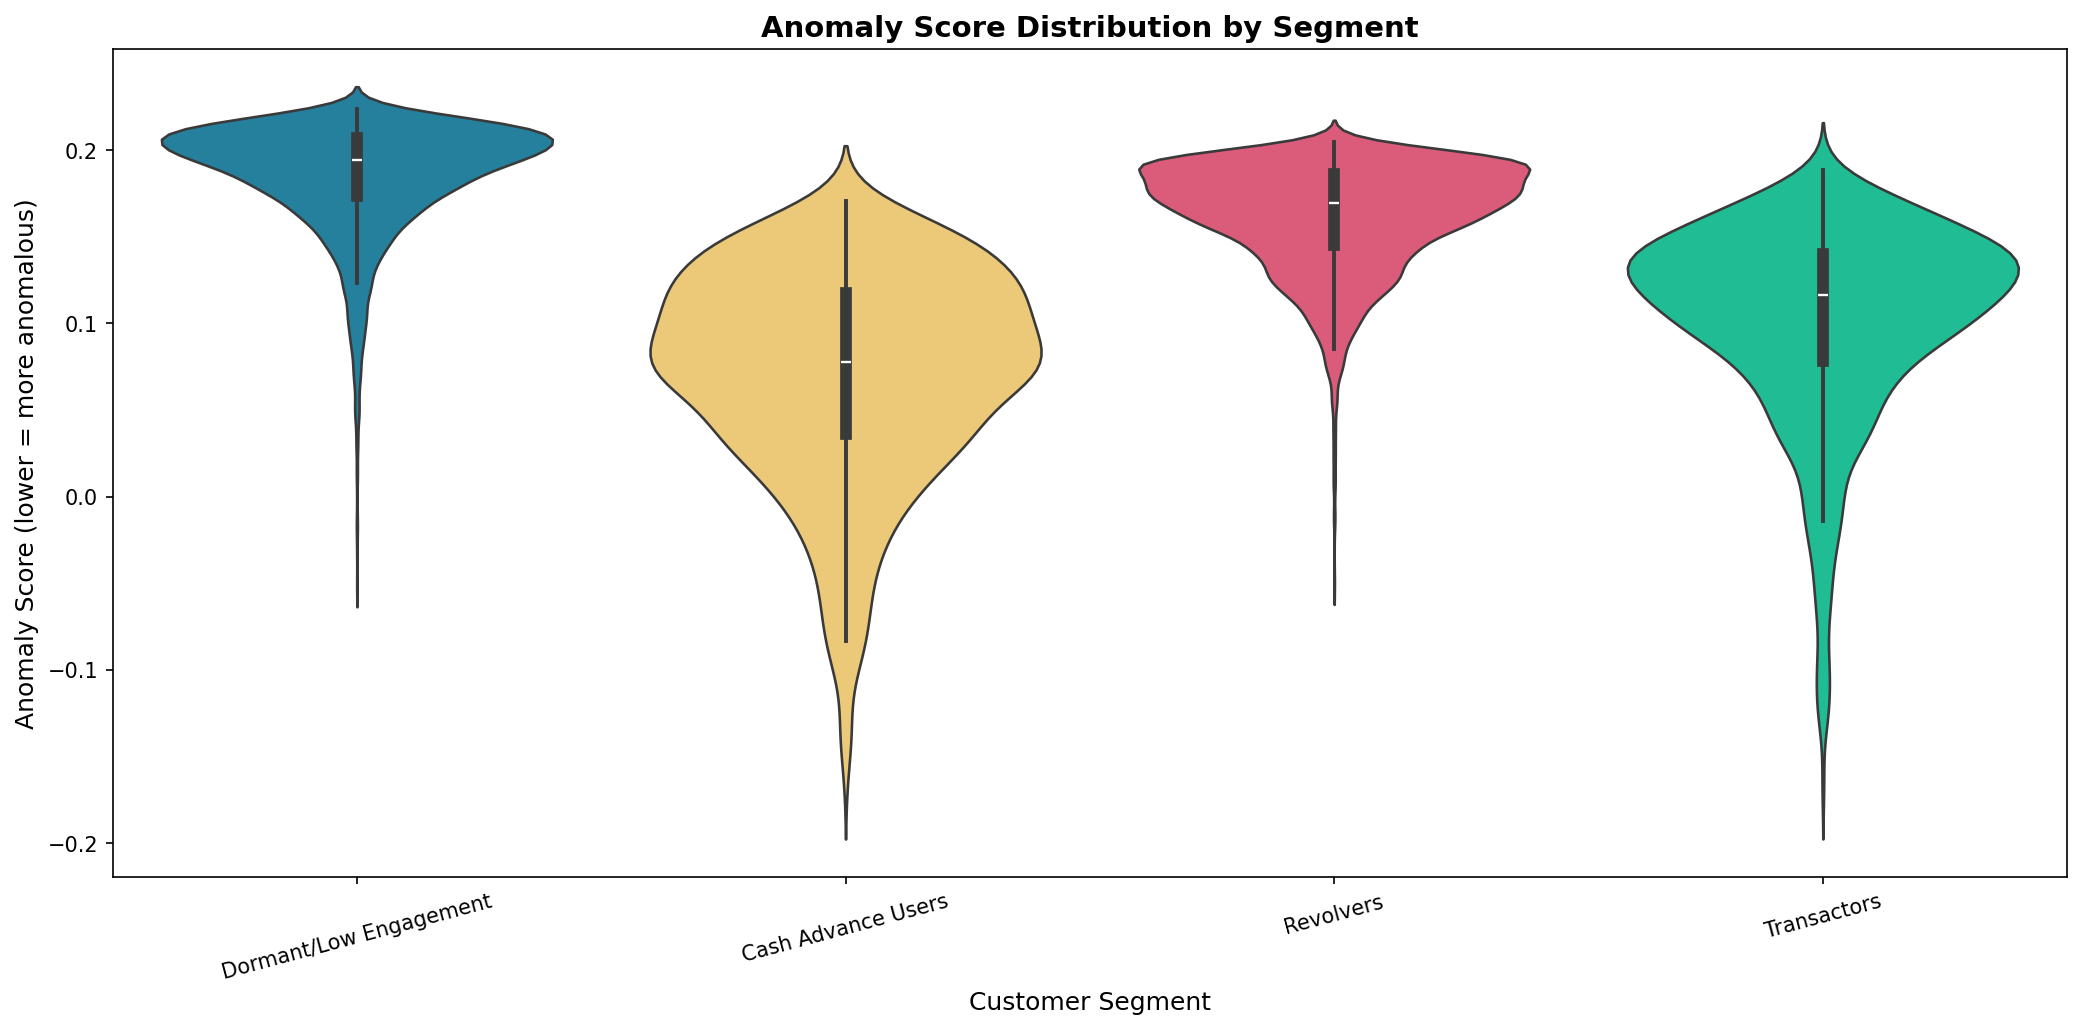


────────────────────────────────────────────────────────────
  09_fraud_risk_scatter.png
────────────────────────────────────────────────────────────


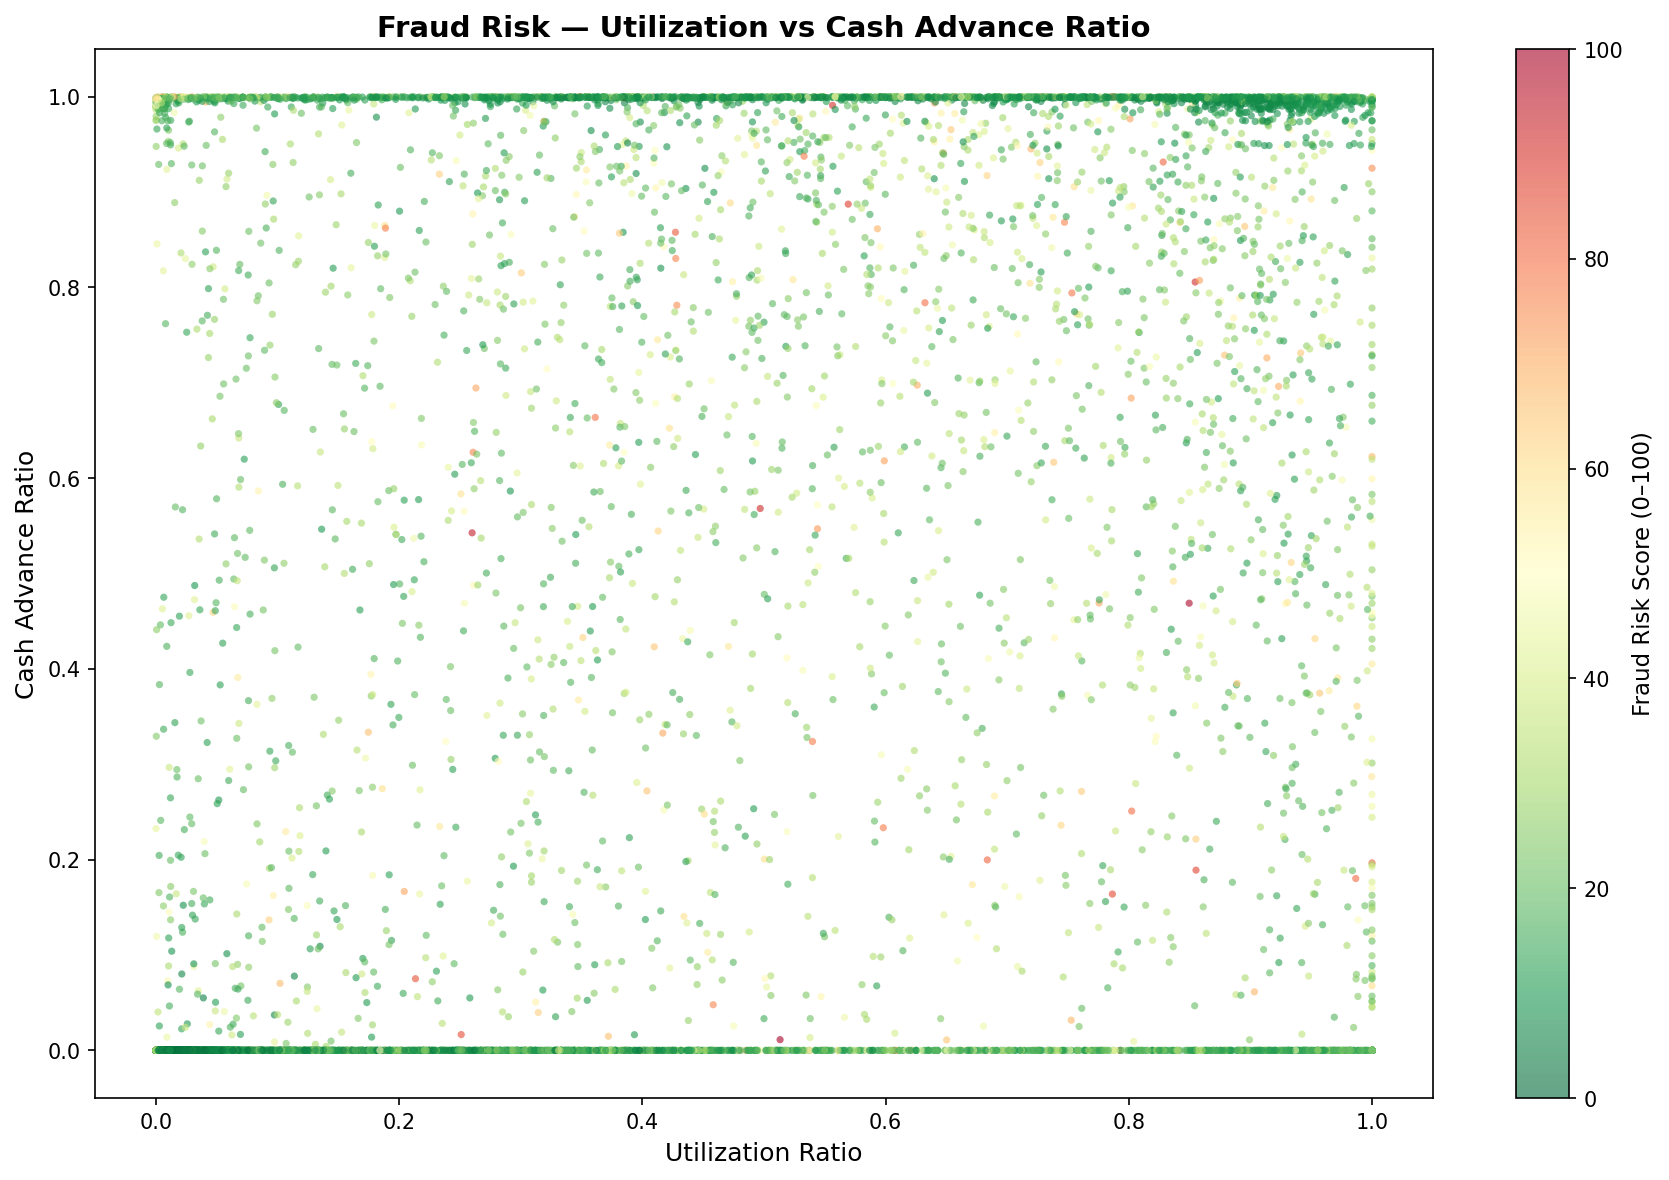

In [7]:
from IPython.display import Image
from src.utils import PLOTS_DIR

for plot_file in sorted(PLOTS_DIR.glob("0[8-9]_*.png")):
    print(f"\n{'\u2500' * 60}")
    print(f"  {plot_file.name}")
    print(f"{'\u2500' * 60}")
    display(Image(filename=str(plot_file), width=900))

## 6. Save Master Dataset

The final master dataframe contains:
- All 17 original features
- 6 engineered behavioural ratios
- Cluster labels (CLUSTER_ID + SEGMENT_NAME)
- PCA coordinates (PC1, PC2)
- Classic outlier flags
- Isolation Forest scores (ANOMALY_SCORE, ANOMALY_FLAG, FRAUD_RISK_SCORE)

In [8]:
from src.anomaly import save_master_data

save_master_data(df)

  ✓ Master data saved → data\processed\master_customers.csv (8949 rows, 34 cols)


In [9]:
# Final column inventory
print(f"\nMaster dataframe: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns ({df.shape[1]}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")


Master dataframe: 8949 rows, 34 columns

Columns (34):
   1. BALANCE
   2. BALANCE_FREQUENCY
   3. PURCHASES
   4. ONEOFF_PURCHASES
   5. INSTALLMENTS_PURCHASES
   6. CASH_ADVANCE
   7. PURCHASES_FREQUENCY
   8. ONEOFF_PURCHASES_FREQUENCY
   9. PURCHASES_INSTALLMENTS_FREQUENCY
  10. CASH_ADVANCE_FREQUENCY
  11. CASH_ADVANCE_TRX
  12. PURCHASES_TRX
  13. CREDIT_LIMIT
  14. PAYMENTS
  15. MINIMUM_PAYMENTS
  16. PRC_FULL_PAYMENT
  17. TENURE
  18. UTILIZATION_RATIO
  19. PAYMENT_TO_BALANCE
  20. SPEND_VELOCITY
  21. INSTALLMENT_FREQUENCY
  22. CASH_ADVANCE_RATIO
  23. PURCHASE_TYPE_RATIO
  24. CLUSTER_ID
  25. SEGMENT_NAME
  26. PC1
  27. PC2
  28. BALANCE_OUTLIER
  29. PURCHASE_OUTLIER
  30. CASH_OUTLIER
  31. CLASSIC_OUTLIER_FLAG
  32. ANOMALY_SCORE
  33. ANOMALY_FLAG
  34. FRAUD_RISK_SCORE


## 7. Key Observations

- The Isolation Forest flags exactly **2.3%** of customers as
  anomalous, matching the target contamination rate.
- **Cash Advance Users** and **Revolvers** contain the highest
  concentration of anomalies, consistent with their risk profiles.
- The cross-tabulation shows meaningful agreement between
  classic outlier flags and Isolation Forest predictions — the
  two methods reinforce each other's findings.
- The fraud risk scatter clearly separates high-risk customers
  (top-right quadrant: high utilisation + high cash advance ratio).

---
*Next: [05_Business_Insights.ipynb](05_Business_Insights.ipynb) →
generate the persona report and Power BI exports.*